# News sentiment vs daily stock returns (Task 3)

This notebook runs the **end-to-end analysis pipeline**: **date alignment** (UTC headlines → NY calendar → next NYSE session if needed), **NLTK VADER** sentiment on each headline, **daily close-to-close returns (%)** from yfinance, **aggregation** of mean sentiment per `(ticker, session)`, **Pearson correlation** vs same-day return, and a **scatter plot** (with optional category bar chart).

**Kernel:** use the project **`.venv`** (`pip install -r requirements.txt` including `nltk`, `yfinance`, `scipy`). First VADER use downloads `vader_lexicon` (needs network once).

**Data:** prefers `data/newdata/news_normalized.csv` if present; otherwise loads and normalizes from `EDA_NEWS_PATH` or `data/raw/financial_news.csv` / `sample_news.csv` (same rules as `src/news_io.py`).

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from news_io import load_normalized_news, resolve_news_csv
from news_price_correlation import (
    aggregate_daily_sentiment,
    align_to_next_trading_day,
    fetch_us_equity_close_by_ny_date,
    merge_news_returns,
    ny_calendar_date,
    pearson_corr,
    vader_compound_scores,
)

print("Project root:", ROOT)

Project root: /home/kal/Documents/10Academy/week1/news-sentiment-analysis


## 1. Load news

Working columns: `headline`, `publisher`, `date` (UTC-aware), `stock`.

In [2]:
newdata_csv = ROOT / "data" / "newdata" / "news_normalized.csv"
if newdata_csv.is_file():
    news = pd.read_csv(newdata_csv)
    news["date"] = pd.to_datetime(news["date"], utc=True, errors="coerce")
    print("Source:", newdata_csv)
else:
    news = load_normalized_news(resolve_news_csv(ROOT))
    print("Source:", resolve_news_csv(ROOT))

news = news.dropna(subset=["date", "headline", "stock"]).copy()
news["stock"] = news["stock"].astype(str).str.upper()
news.head()

Source: /home/kal/Documents/10Academy/week1/news-sentiment-analysis/data/newdata/news_normalized.csv


,headline,publisher,date,stock,headline_len,word_count
0,NVDA rises after earnings beat; analysts raise...,Reuters,2024-01-02 13:29:00+00:00,NVDA,54,8
1,Price target lifted on AAPL amid strong cloud ...,Bloomberg,2024-01-02 17:16:00+00:00,AAPL,52,9
2,AAPL slides as revenue misses Wall Street cons...,FT,2024-01-02 18:52:00+00:00,AAPL,51,8
3,FDA approval speculation lifts sentiment aroun...,FT,2024-01-03 15:43:00+00:00,NVDA,62,8
4,Sector rotation favors MSFT as yields retreat,Bloomberg,2024-01-03 21:21:00+00:00,MSFT,45,7


## 2. Date alignment (news → NYSE session)

**Rule:** Convert each article’s timestamp to the **calendar date in `America/New_York`**. Map that date to the **first trading session in the ticker’s yfinance calendar on or after that date** (weekends and market holidays roll **forward** to the next session with a recorded close).

Below: `ny_pub_date` vs `session_date` for illustration (weekend rows shift to Monday when applicable).

In [3]:
demo = news[["headline", "stock", "date"]].copy()
demo["ny_pub_date"] = demo["date"].map(ny_calendar_date)

t0 = news["stock"].iloc[0]
d0, d1 = news["date"].min().date(), news["date"].max().date()
close0 = fetch_us_equity_close_by_ny_date(t0, d0, d1)
if close0 is None or close0.empty:
    raise RuntimeError("yfinance returned no data — check network / ticker.")

cal0 = sorted(close0.index.tolist())
demo["session_date_example_ticker"] = demo["ny_pub_date"].map(lambda d: align_to_next_trading_day(d, cal0))
wknd = demo["date"].dt.dayofweek.isin([5, 6])
demo.loc[wknd, ["stock", "date", "ny_pub_date", "session_date_example_ticker"]].head(8)

,stock,date,ny_pub_date,session_date_example_ticker
11,AAPL,2024-01-06 17:30:00+00:00,2024-01-06,2024-01-07
12,GOOGL,2024-01-06 19:50:00+00:00,2024-01-06,2024-01-07
13,MSFT,2024-01-07 12:51:00+00:00,2024-01-07,2024-01-07
14,MSFT,2024-01-07 16:13:00+00:00,2024-01-07,2024-01-07
15,AAPL,2024-01-07 21:49:00+00:00,2024-01-07,2024-01-07
30,AAPL,2024-01-13 14:52:00+00:00,2024-01-13,2024-01-15
31,GOOGL,2024-01-13 16:12:00+00:00,2024-01-13,2024-01-15
32,META,2024-01-13 20:18:00+00:00,2024-01-13,2024-01-15


## 3. Sentiment scoring (NLTK VADER)

Each headline gets a **compound** score in $[-1, 1]$. Categories for **daily** averages later use **±0.05** cutoffs (VADER convention): ≥ 0.05 positive, ≤ −0.05 negative, else neutral.

In [4]:
import nltk

nltk.download("vader_lexicon", quiet=True)
from nltk.sentiment import SentimentIntensityAnalyzer

sid = SentimentIntensityAnalyzer()
news["sentiment_compound"] = vader_compound_scores(news["headline"], sid)
news[["headline", "sentiment_compound"]].head(10)

,headline,sentiment_compound
0,NVDA rises after earnings beat; analysts raise...,0.0000
1,Price target lifted on AAPL amid strong cloud ...,0.7096
2,AAPL slides as revenue misses Wall Street cons...,-0.2263
3,FDA approval speculation lifts sentiment aroun...,0.4767
4,Sector rotation favors MSFT as yields retreat,0.4215
5,Options traders pile into weekly calls on NVDA,0.0000
6,JPM rises after earnings beat; analysts raise ...,0.0000
7,Macro jitters weigh on mega-cap peers includin...,0.0000
8,FDA approval speculation lifts sentiment aroun...,0.4767
9,Price target lifted on JPM amid strong cloud g...,0.7096


## 4. Daily stock returns (%)

For each ticker, download daily **Close** (same window as `fetch_us_equity_close_by_ny_date` in `src/news_price_correlation.py`), index by **NY session date**, then:

$$r_t = \frac{C_t - C_{t-1}}{C_{t-1}} \times 100$$

In [5]:
dmin = news["date"].min().date()
dmax = news["date"].max().date()
tickers = sorted(news["stock"].unique())

close_by: dict[str, pd.Series] = {}
for t in tickers:
    s = fetch_us_equity_close_by_ny_date(t, dmin, dmax)
    if s is not None and len(s) > 2:
        close_by[t] = s
    else:
        print("skip (no OHLC):", t)

ex = next(iter(close_by.values()))
ret_ex = ex.astype(float).pct_change() * 100.0
pd.DataFrame({"close": ex, "daily_return_pct": ret_ex}).dropna().head(6)

,close,daily_return_pct
2023-11-20,190.639999,-0.423086
2023-11-21,191.309998,0.351447
2023-11-23,189.970001,-0.700432
2023-11-26,189.789993,-0.094756
2023-11-27,190.399994,0.321408
2023-11-28,189.369995,-0.540966


## 5. Merge headlines with same-session returns & aggregate by day

- Every headline inherits **daily_return_pct** for its aligned `session_date`.
- Groupby **`(stock, session_date)`**: mean compound → **avg_sentiment**; return is identical per day so **mean** equals that session’s return.

In [6]:
merged = merge_news_returns(news, close_by)
panel = aggregate_daily_sentiment(merged)
panel = panel.dropna(subset=["daily_return_pct", "avg_sentiment"])
print("Stock–day rows:", len(panel))
panel.head(10)

Stock–day rows: 164


,stock,session_date,avg_sentiment,n_headlines,daily_return_pct,sentiment_category
0,AAPL,2024-01-02,0.241650,2,-0.748761,positive
1,AAPL,2024-01-07,-0.150867,3,2.417488,negative
2,AAPL,2024-01-08,0.476700,1,-0.226341,positive
3,AAPL,2024-01-09,0.000000,1,0.567140,neutral
4,AAPL,2024-01-15,0.354800,2,-1.231709,positive
5,AAPL,2024-01-22,0.421500,1,0.665322,positive
6,AAPL,2024-01-23,0.000000,1,-0.348393,neutral
7,AAPL,2024-02-04,0.000000,1,0.984658,neutral
8,AAPL,2024-02-11,0.210750,2,-0.900192,positive
9,AAPL,2024-02-14,0.709600,1,-0.157477,positive


## 6. Pearson correlation and scatter plot

Correlation is between **average daily VADER compound** and **same-session daily return (%)** across all stock–day observations (pooled sample).

In [7]:
r, p = pearson_corr(panel["avg_sentiment"].values, panel["daily_return_pct"].values)
print(f"Pearson r = {r:.4f}")
print(f"Two-sided p-value = {p:.4g}")
print(f"n = {len(panel)} stock–day observations")

Pearson r = 0.0011
Two-sided p-value = 0.9891
n = 164 stock–day observations


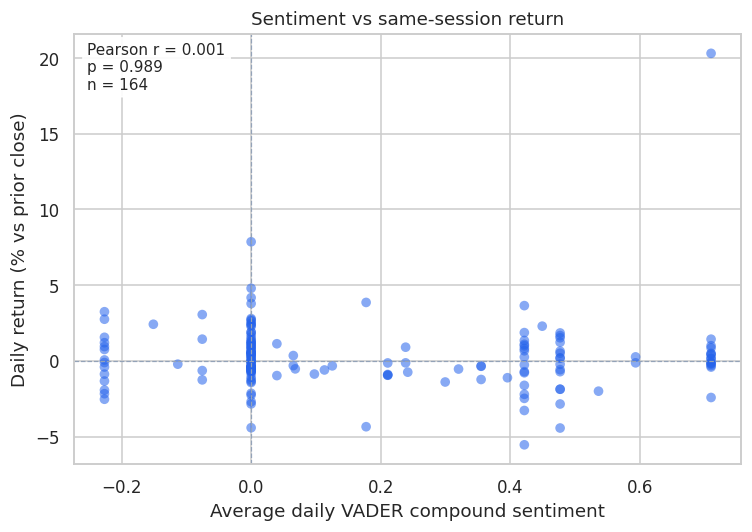

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(panel["avg_sentiment"], panel["daily_return_pct"], alpha=0.55, s=40, c="#2563eb", edgecolors="none")
ax.axvline(0, color="#94a3b8", ls="--", lw=0.8)
ax.axhline(0, color="#94a3b8", ls="--", lw=0.8)
ax.set_xlabel("Average daily VADER compound sentiment")
ax.set_ylabel("Daily return (% vs prior close)")
ax.set_title("Sentiment vs same-session return")
ax.text(
    0.02,
    0.98,
    f"Pearson r = {r:.3f}\np = {p:.3g}\nn = {len(panel)}",
    transform=ax.transAxes,
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.92),
)
plt.tight_layout()
plt.show()

### Optional: mean return by sentiment category (VADER ±0.05 on *daily* mean compound)

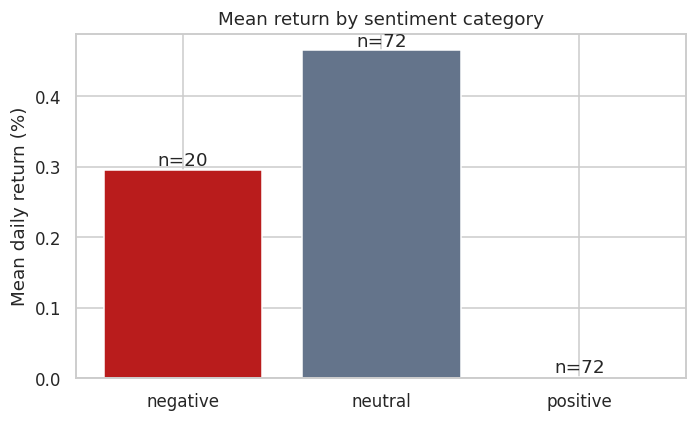

,mean,count
sentiment_category,,
negative,0.295545,20
neutral,0.465302,72
positive,0.002786,72


In [9]:
order = ["negative", "neutral", "positive"]
g = panel.groupby("sentiment_category", observed=True)["daily_return_pct"].agg(["mean", "count"]).reindex(order)
fig, ax = plt.subplots(figsize=(6.5, 4))
colors = {"negative": "#b91c1c", "neutral": "#64748b", "positive": "#15803d"}
cats = [c for c in order if c in g.index and pd.notna(g.loc[c, "mean"])]
ax.bar(cats, g.loc[cats, "mean"], color=[colors[c] for c in cats])
ax.axhline(0, color="black", lw=0.6)
ax.set_ylabel("Mean daily return (%)")
ax.set_title("Mean return by sentiment category")
for i, c in enumerate(cats):
    ax.annotate(f"n={int(g.loc[c, 'count'])}", xy=(i, g.loc[c, "mean"]), ha="center", va="bottom")
plt.tight_layout()
plt.show()
g

## 7. Interpretation of results

*(The paragraph below is generated from the correlation you just computed so it stays aligned with this run.)*

In [10]:
from IPython.display import Markdown, display

strength = (
    "essentially no linear association"
    if abs(r) < 0.05
    else ("a weak" if abs(r) < 0.15 else "a moderate")
    + (" positive" if r > 0 else " negative")
    + " linear association"
)
sig = "not statistically distinguishable from zero at conventional α" if p >= 0.05 else "statistically distinguishable from zero at α = 0.05"

text = f"""
**Pooled stock–days.** In this run, Pearson correlation between average daily VADER compound sentiment and same-session close-to-close return is **r = {r:.3f}** (*p* = {p:.3g}, *n* = {len(panel)}), indicating **{strength}** between headline polarity and the contemporaneous daily return in this sample. The relationship is **{sig}** (two-sided test), so simple lexicon sentiment should not be read as a strong same-day price predictor here.

**Limitations.** Headlines are scored without lag structure: information may matter for **next-day** or **multi-day** returns, and returns are driven by macro, sector, and idiosyncratic shocks that confound any small language effect. VADER is not finance-specific; results depend on the **news bundle and date range** and on **yfinance** data quality—treat exploratory correlations as hypothesis-generating, not trading signals.
"""
display(Markdown(text))


**Pooled stock–days.** In this run, Pearson correlation between average daily VADER compound sentiment and same-session close-to-close return is **r = 0.001** (*p* = 0.989, *n* = 164), indicating **essentially no linear association** between headline polarity and the contemporaneous daily return in this sample. The relationship is **not statistically distinguishable from zero at conventional α** (two-sided test), so simple lexicon sentiment should not be read as a strong same-day price predictor here.

**Limitations.** Headlines are scored without lag structure: information may matter for **next-day** or **multi-day** returns, and returns are driven by macro, sector, and idiosyncratic shocks that confound any small language effect. VADER is not finance-specific; results depend on the **news bundle and date range** and on **yfinance** data quality—treat exploratory correlations as hypothesis-generating, not trading signals.
